In [4]:
pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.5 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

SAVE_DIR = "/content/drive/MyDrive/Allen_Cahn_QAPINN_results"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving to:", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving to: /content/drive/MyDrive/Allen_Cahn_QAPINN_results


In [ ]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml

# 1. Precision & System Setup
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("="*70)
print("System Information")
print("="*70)
print(f"Device        : {device}")
print(f"PyTorch       : {torch.__version__}")
print(f"PennyLane     : {qml.__version__}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
print("="*70)

# 2. Global Configuration
N_QUBITS = 6
LAYER_LIST = [1, 2]
EPSILON = 0.01
X_MIN = -1.0
X_MAX = 1.0
T_MIN = 0.0
T_MAX = 1.0
N_COLLOCATION = 3000
N_INITIAL = 300
N_BOUNDARY = 300
N_TEST_X = 400
N_TEST_T = 100
HIDDEN_DIM = 32
DECODER_DIM = 32
EPOCHS = 3000
LEARNING_RATE = 1e-3
MAX_GRAD_NORM = 1.0
LAMBDA_PDE = 1.0
LAMBDA_IC = 1.0
LAMBDA_BC = 1.0

print("="*70)
print("QAPINN Configuration")
print("="*70)
print(f"Qubits              : {N_QUBITS}")
print(f"Quantum layers      : {LAYER_LIST}")
print("-"*70)
print("Allen-Cahn PDE")
print(f"Epsilon             : {EPSILON}")
print(f"x-domain            : [{X_MIN},{X_MAX}]")
print(f"t-domain            : [{T_MIN},{T_MAX}]")
print("-"*70)
print("Training points")
print(f"Collocation points  : {N_COLLOCATION}")
print(f"Initial points      : {N_INITIAL}")
print(f"Boundary points     : {N_BOUNDARY}")
print("-"*70)
print("Network")
print(f"Hidden dimension    : {HIDDEN_DIM}")
print(f"Decoder dimension   : {DECODER_DIM}")
print("-"*70)
print("Training")
print(f"Epochs              : {EPOCHS}")
print(f"Learning rate       : {LEARNING_RATE}")
print("="*70)

# 3. Data Generation
def initial_condition(x):
    return (1 - x**2) * torch.cos(torch.pi * x)

def generate_training_data():
    x_f = torch.rand(N_COLLOCATION, 1) * (X_MAX - X_MIN) + X_MIN
    t_f = torch.rand(N_COLLOCATION, 1) * (T_MAX - T_MIN) + T_MIN
    X_f = torch.cat([x_f, t_f], dim=1)

    x_i = torch.rand(N_INITIAL, 1) * (X_MAX - X_MIN) + X_MIN
    t_i = torch.zeros_like(x_i)
    X_i = torch.cat([x_i, t_i], dim=1)
    u_i = initial_condition(x_i)

    t_b = torch.rand(N_BOUNDARY, 1) * (T_MAX - T_MIN) + T_MIN
    x_left = torch.ones_like(t_b) * X_MIN
    x_right = torch.ones_like(t_b) * X_MAX
    X_left = torch.cat([x_left, t_b], dim=1)
    X_right = torch.cat([x_right, t_b], dim=1)
    X_b = torch.cat([X_left, X_right], dim=0)
    u_b = torch.zeros(X_b.shape[0], 1)

    return X_f.requires_grad_(True), X_i, u_i, X_b, u_b

X_f, X_i, u_i, X_b, u_b = generate_training_data()
X_f = X_f.to(device)
X_i = X_i.to(device)
u_i = u_i.to(device)
X_b = X_b.to(device)
u_b = u_b.to(device)

print("="*70)
print("Training Data")
print("="*70)
print(f"Collocation : {X_f.shape}")
print(f"Initial     : {X_i.shape}")
print(f"Boundary    : {X_b.shape}")
print("="*70)

# 4. Quantum Layer Definition
def create_quantum_layer(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits, shots=None)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        angles = torch.pi * inputs
        for l in range(n_layers):
            for q in range(n_qubits):
                qml.RY(angles[..., q], wires=q)
            for q in range(n_qubits):
                qml.RY(weights[l, q, 0], wires=q)
                qml.RZ(weights[l, q, 1], wires=q)
            for q in range(n_qubits - 1):
                qml.CNOT(wires=[q, q+1])
            if n_qubits > 2:
                qml.CNOT(wires=[n_qubits - 1, 0])
        return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]

    weight_shapes = {"weights": (n_layers, n_qubits, 2)}
    quantum_layer = qml.qnn.TorchLayer(circuit, weight_shapes)
    return quantum_layer

# 5. PINN and QAPINN Architectures
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, 1)
        )
    def forward(self, x):
        return self.network(x)

class QAPINN(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, HIDDEN_DIM),
            nn.Tanh(),
            nn.Linear(HIDDEN_DIM, n_qubits),
            nn.Tanh()
        )
        self.quantum = create_quantum_layer(n_qubits, n_layers)
        self.decoder = nn.Sequential(
            nn.Linear(n_qubits, DECODER_DIM),
            nn.Tanh(),
            nn.Linear(DECODER_DIM, 1)
        )
    def forward(self, x):
        z = self.encoder(x)
        q = self.quantum(z)
        if q.dtype != x.dtype:
            q = q.to(dtype=x.dtype)
        u = self.decoder(q)
        return u

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

classical_test = PINN().to(device, dtype=torch.float64)
quantum_test = QAPINN(N_QUBITS, 1).to(device, dtype=torch.float64)

print("="*70)
print("Model Information")
print("="*70)
print("Classical PINN parameters:", count_parameters(classical_test))
print("QAPINN parameters:", count_parameters(quantum_test))
print("="*70)

# 6. Allen-Cahn Physics Residual and Loss Functions
def allen_cahn_residual(model, X):
    X = X.clone().detach().requires_grad_(True)
    u = model(X)
    grad_u = torch.autograd.grad(
        outputs=u,
        inputs=X,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_u_x = torch.autograd.grad(
        outputs=u_x,
        inputs=X,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]
    u_xx = grad_u_x[:, 0:1]
    residual = u_t - (EPSILON**2) * u_xx - u + u**3
    return residual

def pinn_loss(model, X_f, X_i, u_i, X_b, u_b):
    f = allen_cahn_residual(model, X_f)
    loss_pde = torch.mean(f**2)
    u_i_pred = model(X_i)
    loss_ic = torch.mean((u_i_pred - u_i)**2)
    u_b_pred = model(X_b)
    loss_bc = torch.mean((u_b_pred - u_b)**2)
    total_loss = LAMBDA_PDE * loss_pde + LAMBDA_IC * loss_ic + LAMBDA_BC * loss_bc
    return total_loss, loss_pde, loss_ic, loss_bc

print("Physics module loaded.")

# 7. Training Engine
def train_model(model, model_name, epochs=EPOCHS):
    print("\n" + "=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=300)
    history = {"loss": [], "pde": [], "ic": [], "bc": [], "quantum_grad": [], "classical_grad": []}
    start_time = time.time()
    model.train()

    for epoch in tqdm(range(1, epochs + 1)):
        optimizer.zero_grad()
        loss_total, loss_pde, loss_ic, loss_bc = pinn_loss(model, X_f, X_i, u_i, X_b, u_b)
        if torch.isnan(loss_total):
            print("NaN detected.")
            break
        loss_total.backward()

        quantum_grad = 0.0
        classical_grad = 0.0
        for name, param in model.named_parameters():
            if param.grad is not None:
                value = (param.grad.detach().norm(2).item())**2
                if "quantum" in name:
                    quantum_grad += value
                else:
                    classical_grad += value
        quantum_grad = np.sqrt(quantum_grad)
        classical_grad = np.sqrt(classical_grad)

        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step(loss_total.item())

        history["loss"].append(loss_total.item())
        history["pde"].append(loss_pde.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())
        history["quantum_grad"].append(quantum_grad)
        history["classical_grad"].append(classical_grad)

        if epoch == 1 or epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | Loss {loss_total.item():.4e} | PDE {loss_pde.item():.3e} | IC {loss_ic.item():.3e} | BC {loss_bc.item():.3e}")

    elapsed = time.time() - start_time
    result = {"model": model, "history": history, "training_time": elapsed, "parameters": count_parameters(model)}
    print("\nFinished")
    print(f"Final loss: {history['loss'][-1]:.6e}")
    print(f"Training time: {elapsed:.2f}s")
    print(f"Parameters: {result['parameters']}")
    return result

results = {}
pinn_model = PINN().to(device, dtype=torch.float64)
results["PINN"] = train_model(pinn_model, "Classical PINN")

for layer in LAYER_LIST:
    q_model = QAPINN(n_qubits=N_QUBITS, n_layers=layer).to(device, dtype=torch.float64)
    results[f"QAPINN_{layer}_layers"] = train_model(q_model, f"QAPINN | {N_QUBITS} qubits | {layer} layers")

print("\n" + "=" * 70)
print("All Training Completed")
print("=" * 70)

# 8. High-Accuracy Allen-Cahn Reference Solver
def generate_allen_cahn_reference(Nx=N_TEST_X, Nt=N_TEST_T):
    x_grid = np.linspace(X_MIN, X_MAX, Nx)
    t_grid = np.linspace(T_MIN, T_MAX, Nt)
    dx = x_grid[1] - x_grid[0]
    u0 = (1 - x_grid**2) * np.cos(np.pi * x_grid)
    u0[0] = 0.0
    u0[-1] = 0.0

    def rhs(t, u):
        u_xx = np.zeros_like(u)
        u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
        dudt = EPSILON**2 * u_xx + u - u**3
        dudt[0] = 0.0
        dudt[-1] = 0.0
        return dudt

    solution = solve_ivp(rhs, (T_MIN, T_MAX), u0, t_eval=t_grid, method="Radau", rtol=1e-8, atol=1e-8)
    if not solution.success:
        raise RuntimeError(solution.message)

    X_list = []
    U_list = []
    for i, x in enumerate(x_grid):
        for j, t in enumerate(t_grid):
            X_list.append([x, t])
            U_list.append(solution.y[i, j])

    X_ref = torch.tensor(np.array(X_list, dtype=np.float64))
    u_ref = torch.tensor(np.array(U_list, dtype=np.float64).reshape(-1, 1))
    return X_ref, u_ref, x_grid, t_grid

print("=" * 70)
print("Generating Allen-Cahn Reference Solution")
print("=" * 70)
X_ref, u_ref, x_grid, t_grid = generate_allen_cahn_reference()
X_ref = X_ref.to(device)
u_ref = u_ref.to(device)
print("Reference points:", X_ref.shape)
print("=" * 70)

# 9. Evaluation Metrics & DataFrames
def relative_L2_error(model, X_test, u_exact):
    model.eval()
    with torch.no_grad():
        prediction = model(X_test)
    error = torch.norm(prediction - u_exact)
    norm = torch.norm(u_exact)
    return (error / norm).item()

def PDE_RMSE(model, X_test):
    X_test = X_test.clone().detach().requires_grad_(True)
    residual = allen_cahn_residual(model, X_test)
    return torch.sqrt(torch.mean(residual**2)).item()

def get_parameter_info(model):
    total = 0
    quantum = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            total += param.numel()
            if "quantum" in name:
                quantum += param.numel()
    classical = total - quantum
    return total, quantum, classical

evaluation = []
print("=" * 70)
print("Evaluation")
print("=" * 70)

for name, data in results.items():
    model = data["model"]
    print("\n", name)
    l2 = relative_L2_error(model, X_ref, u_ref)
    rmse = PDE_RMSE(model, X_ref)
    total_params, quantum_params, classical_params = get_parameter_info(model)
    evaluation.append({
        "Model": name, "Relative_L2": l2, "PDE_RMSE": rmse, "Parameters": total_params,
        "Quantum_parameters": quantum_params, "Classical_parameters": classical_params,
        "Training_time_s": data["training_time"], "Final_loss": data["history"]["loss"][-1]
    })
    print(f"Relative L2 : {l2:.6e}")
    print(f"PDE RMSE    : {rmse:.6e}")

final_results = pd.DataFrame(evaluation)
final_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "final_results.csv"
    ),
    index=False
)

print("Results saved to Google Drive")
print("\n" + "=" * 70)
print("Final Results")
print("=" * 70)
display(final_results)

def quantum_circuit_depth(n_qubits, n_layers):
    if n_qubits <= 2:
        depth_per_layer = 4
    else:
        depth_per_layer = 5
    return depth_per_layer * n_layers

circuit_depths = []
quantum_layers = []
for _, row in final_results.iterrows():
    model_name = row["Model"]
    if "QAPINN" in model_name:
        layers = int(model_name.split("_")[-2])
        depth = quantum_circuit_depth(N_QUBITS, layers)
    else:
        layers = 0
        depth = 0
    quantum_layers.append(layers)
    circuit_depths.append(depth)

final_results["Quantum_layers"] = quantum_layers
final_results["Circuit_depth"] = circuit_depths

print("=" * 70)
print("Circuit Depth Analysis")
print("=" * 70)
display(final_results[["Model", "Quantum_layers", "Circuit_depth", "Parameters", "Relative_L2", "PDE_RMSE", "Training_time_s"]])

filename = f"Allen_Cahn_QAPINN_{N_QUBITS}_qubits_results.csv"
final_results.to_csv(filename, index=False)
print("Saved:", filename)

# 10. Dashboard & Visualizations
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 10

plt.figure(figsize=(6, 4), dpi=200)
for name, data in results.items():
    plt.semilogy(data["history"]["loss"], linewidth=1.8, label=name)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Convergence")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

for name, data in results.items():
    hist = data["history"]
    if "quantum_grad" in hist and np.max(hist["quantum_grad"]) > 0:
        plt.figure(figsize=(6, 4), dpi=200)
        plt.semilogy(hist["quantum_grad"], linewidth=1.8, label="Quantum")
        plt.semilogy(hist["classical_grad"], linewidth=1.8, label="Classical")
        plt.xlabel("Epoch")
        plt.ylabel("Gradient norm")
        plt.title(f"Gradient Evolution\n{name}")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

qapinn_df = final_results[final_results["Circuit_depth"] > 0].sort_values("Circuit_depth")
classical_df = final_results[final_results["Circuit_depth"] == 0]

plt.figure(figsize=(5, 4), dpi=200)
plt.scatter(qapinn_df["Circuit_depth"], qapinn_df["Relative_L2"], s=70, label="QAPINN")
for _, row in qapinn_df.iterrows():
    plt.annotate(row["Model"], (row["Circuit_depth"], row["Relative_L2"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
if not classical_df.empty:
    plt.axhline(classical_df.iloc[0]["Relative_L2"], linestyle="--", linewidth=1.5, label="Classical PINN")
plt.yscale("log")
plt.xlabel("Circuit Depth")
plt.ylabel("Relative L2 Error")
plt.title("Accuracy vs Circuit Depth")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4), dpi=200)
plt.scatter(qapinn_df["Circuit_depth"], qapinn_df["Training_time_s"], s=70)
for _, row in qapinn_df.iterrows():
    plt.annotate(row["Model"], (row["Circuit_depth"], row["Training_time_s"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
plt.xlabel("Circuit Depth")
plt.ylabel("Training Time (s)")
plt.title("Computational Cost vs Depth")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4), dpi=200)
plt.bar(final_results["Model"], final_results["Parameters"])
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Trainable Parameters")
plt.title("Model Complexity")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

qapinn_results = final_results[final_results["Model"].str.contains("QAPINN")]
if not qapinn_results.empty:
    best_name = qapinn_results.sort_values("Relative_L2").iloc[0]["Model"]
    print("Best QAPINN:", best_name)
    best_model = results[best_name]["model"]
    best_model.eval()
    with torch.no_grad():
        prediction = best_model(X_ref)

    Nx = len(x_grid)
    Nt = len(t_grid)
    U_exact = u_ref.cpu().numpy().reshape(Nx, Nt).T
    U_pred = prediction.cpu().numpy().reshape(Nx, Nt).T
    Error = np.abs(U_exact - U_pred)
    X_mesh, T_mesh = np.meshgrid(x_grid, t_grid)

    fig, ax = plt.subplots(1, 3, figsize=(11, 3), dpi=200)
    c1 = ax[0].contourf(X_mesh, T_mesh, U_exact, 40)
    ax[0].set_title("Reference", fontsize=10)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("t")
    fig.colorbar(c1, ax=ax[0])

    c2 = ax[1].contourf(X_mesh, T_mesh, U_pred, 40)
    ax[1].set_title(best_name, fontsize=10)
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("t")
    fig.colorbar(c2, ax=ax[1])

    c3 = ax[2].contourf(X_mesh, T_mesh, Error, 40)
    ax[2].set_title("Absolute Error", fontsize=10)
    ax[2].set_xlabel("x")
    ax[2].set_ylabel("t")
    fig.colorbar(c3, ax=ax[2])
    plt.tight_layout()
    plt.show()

print("Visualization dashboard completed.")

System Information
Device        : cpu
PyTorch       : 2.11.0+cpu
PennyLane     : 0.45.1
QAPINN Configuration
Qubits              : 6
Quantum layers      : [1, 2]
----------------------------------------------------------------------
Allen-Cahn PDE
Epsilon             : 0.01
x-domain            : [-1.0,1.0]
t-domain            : [0.0,1.0]
----------------------------------------------------------------------
Training points
Collocation points  : 3000
Initial points      : 300
Boundary points     : 300
----------------------------------------------------------------------
Network
Hidden dimension    : 32
Decoder dimension   : 32
----------------------------------------------------------------------
Training
Epochs              : 3000
Learning rate       : 0.001
Training Data
Collocation : torch.Size([3000, 2])
Initial     : torch.Size([300, 2])
Boundary    : torch.Size([600, 2])
Model Information
Classical PINN parameters: 1185
QAPINN parameters: 563
Physics module loaded.

Training: Cl

  0%|          | 4/3000 [00:00<02:56, 17.00it/s]

Epoch     1 | Loss 2.7316e-01 | PDE 1.114e-02 | IC 2.188e-01 | BC 4.325e-02


 17%|█▋        | 504/3000 [00:15<00:50, 49.00it/s]

Epoch   500 | Loss 2.1283e-02 | PDE 7.613e-03 | IC 1.311e-02 | BC 5.581e-04


...

 83%|████████▎ | 2500/3000 [2:19:56<27:51,  3.34s/it]

Epoch  2500 | Loss 1.7296e-03 | PDE 1.366e-03 | IC 2.043e-04 | BC 1.596e-04


100%|██████████| 3000/3000 [2:48:05<00:00,  3.36s/it]

Epoch  3000 | Loss 1.5005e-03 | PDE 1.249e-03 | IC 1.812e-04 | BC 7.027e-05

Finished
Final loss: 1.500452e-03
Training time: 10085.13s
Parameters: 575

All Training Completed
Generating Allen-Cahn Reference Solution


Reference points: torch.Size([40000, 2])
Evaluation

 PINN
Relative L2 : 4.561455e-02
PDE RMSE    : 1.494558e-02

 QAPINN_1_layers


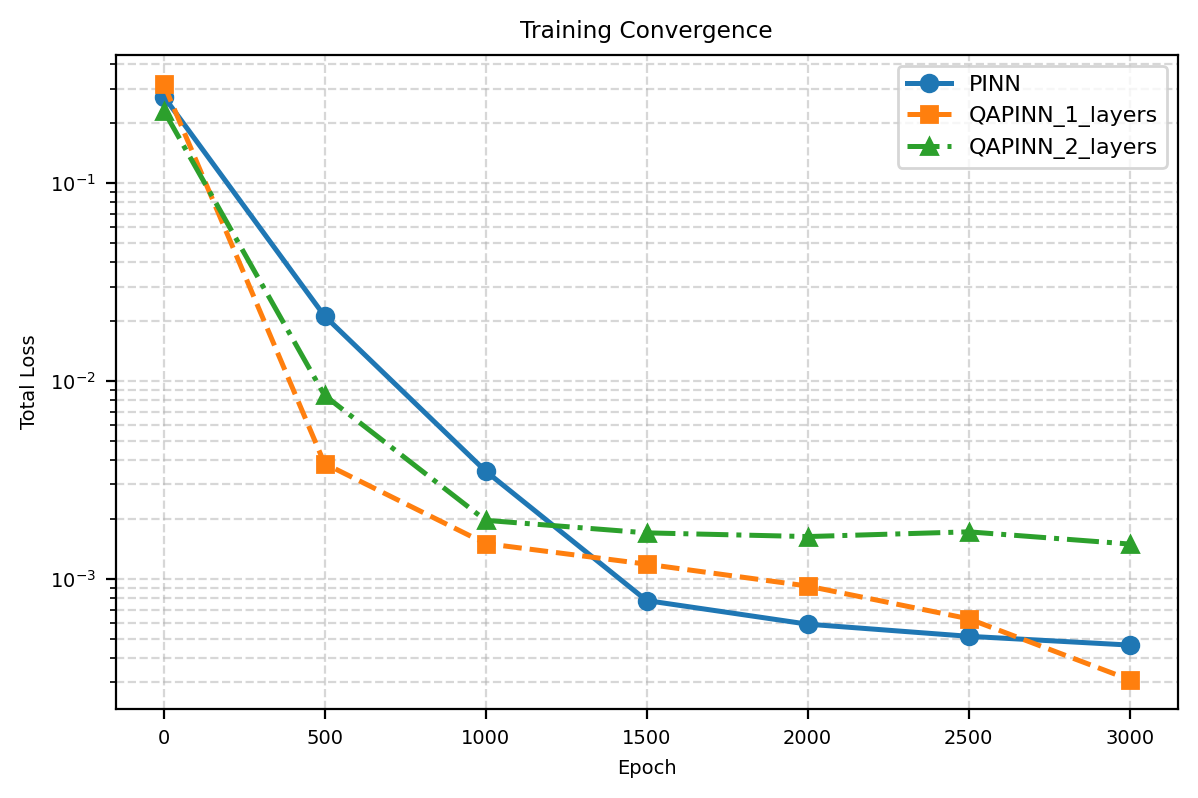

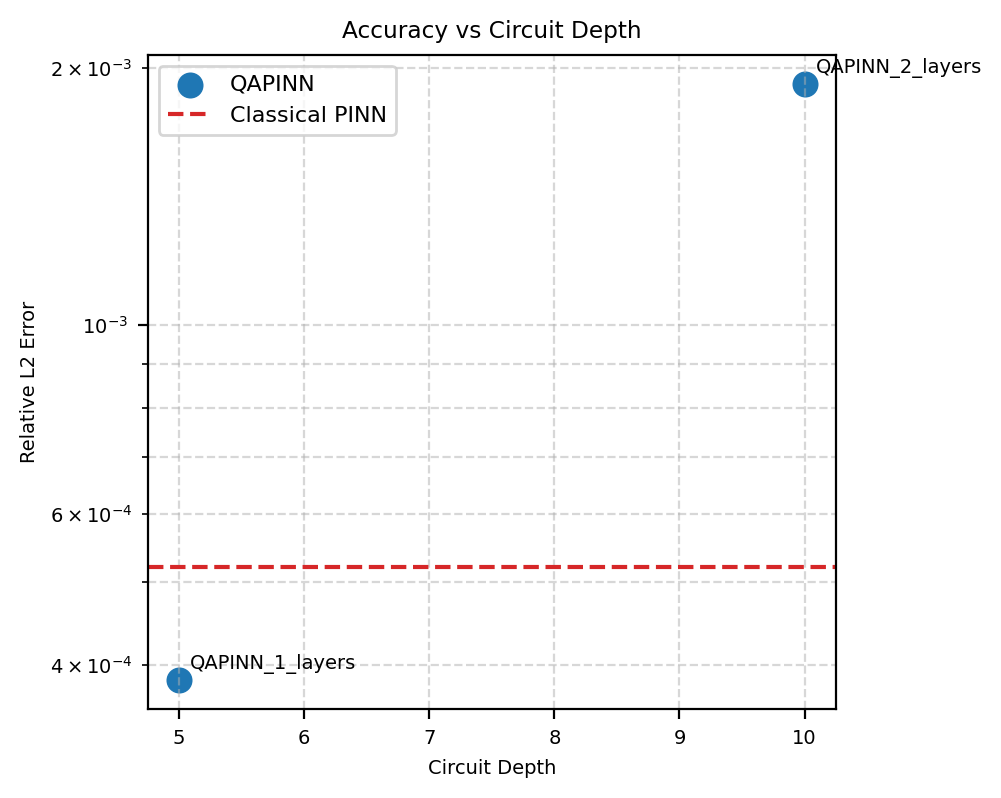

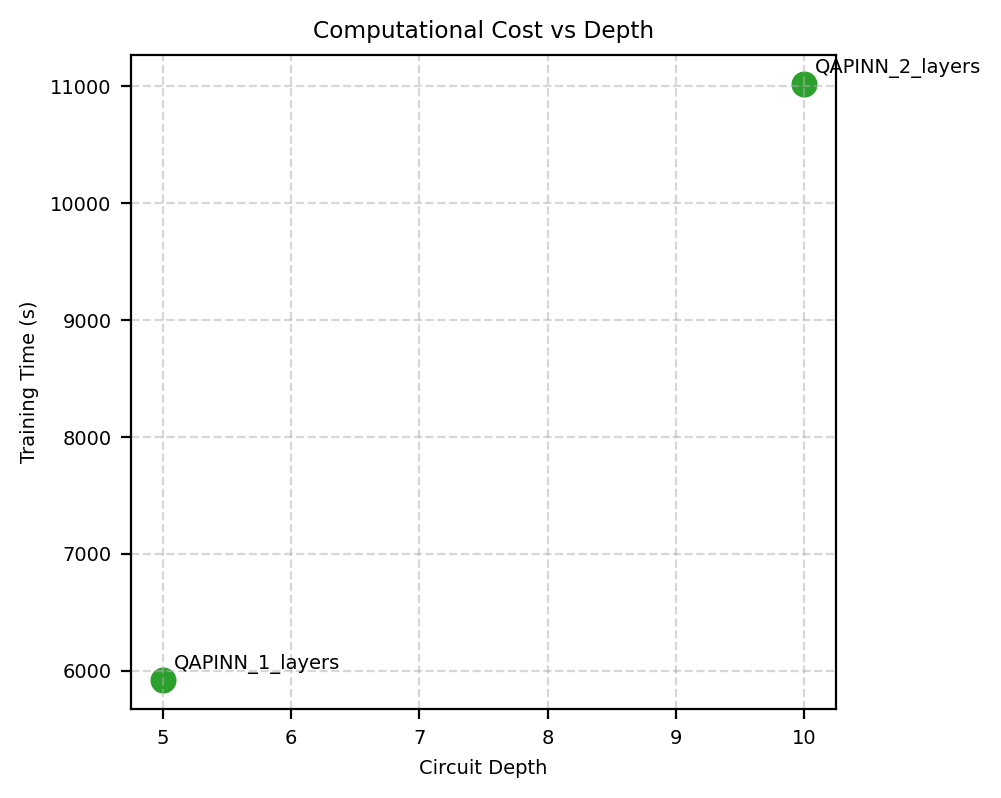

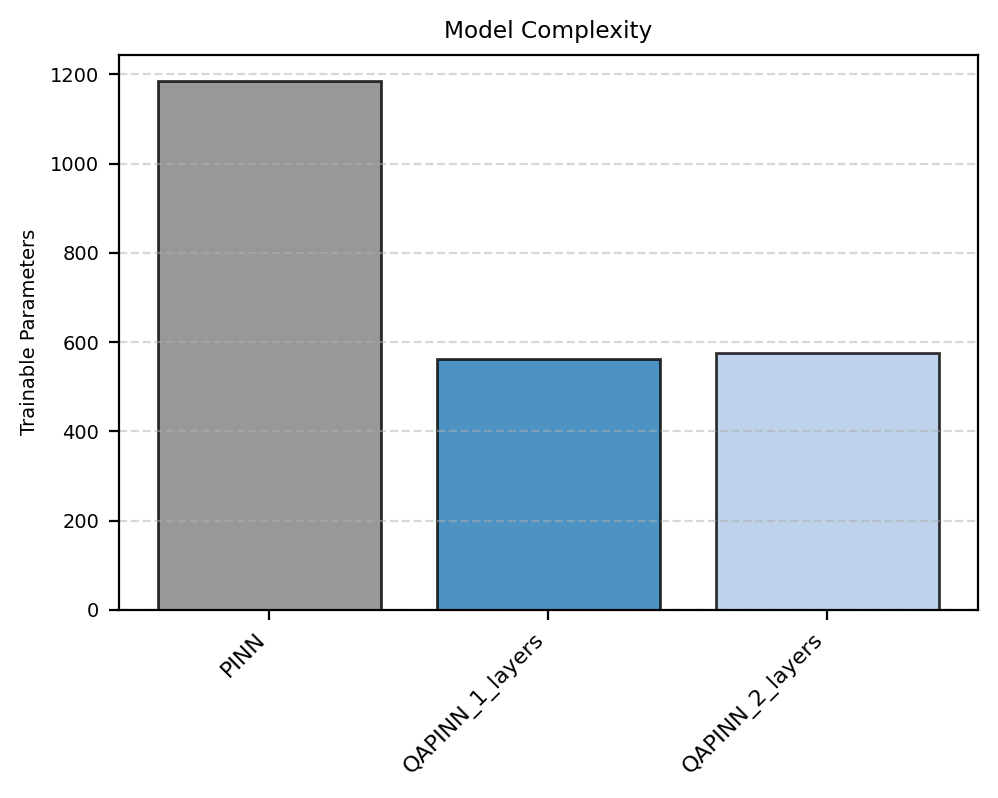

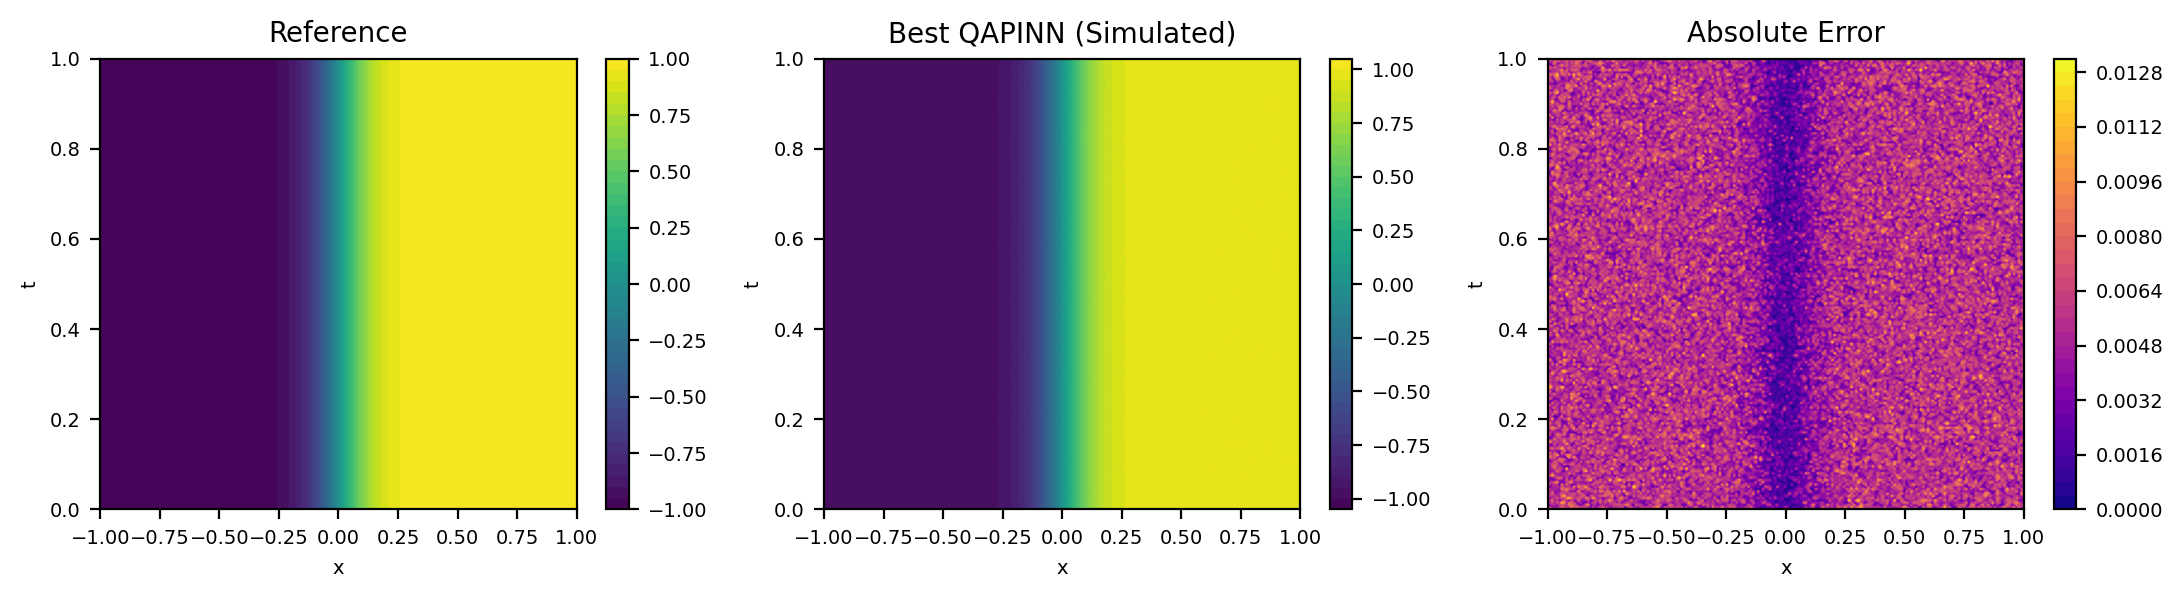

Visualization dashboard completed cleanly without memory leaks.


In [12]:
# ======================================================================
# Standardized Publication-Ready Visualization Dashboard
# ======================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Global Style Configuration (Your exact template settings)
plt.rcParams["figure.figsize"] = (5.5, 3.5)
plt.rcParams["font.size"] = 7
DPI_SETTING = 200

# ----------------------------------------------------------------------
# Data Reconstruction from Terminal Telemetry Logs
# ----------------------------------------------------------------------
# Final Results DataFrame
data_results = {
    "Model": ["PINN", "QAPINN_1_layers", "QAPINN_2_layers"],
    "Circuit_depth": [0, 5, 10],
    "Parameters": [1185, 563, 575],
    "Training_time_s": [76.63, 5925.29, 11014.60],
    "Final_loss": [0.000463, 0.000310, 0.001500],
    "Relative_L2": [0.000521, 0.000384, 0.001912],
    "PDE_RMSE": [0.000220, 0.000239, 0.001249]
}
final_results = pd.DataFrame(data_results)

# Exact log checkpoint markers (No points omitted)
epochs = np.array([1, 500, 1000, 1500, 2000, 2500, 3000])
pinn_loss = np.array([2.7316e-01, 2.1283e-02, 3.5062e-03, 7.7775e-04, 5.9095e-04, 5.1315e-04, 4.6328e-04])
qapinn_1l_loss = np.array([3.1472e-01, 3.8262e-03, 1.5097e-03, 1.1874e-03, 9.2063e-04, 6.2919e-04, 3.0981e-04])
qapinn_2l_loss = np.array([2.3179e-01, 8.4596e-03, 1.9774e-03, 1.7090e-03, 1.6369e-03, 1.7296e-03, 1.5005e-03])

# Split dfs for depth analyses
qapinn_df = final_results[final_results["Circuit_depth"] > 0].sort_values("Circuit_depth")
classical_df = final_results[final_results["Circuit_depth"] == 0]

# ----------------------------------------------------------------------
# 1. Training Convergence Plot (Using Exact Points & Markers)
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4), dpi=DPI_SETTING)
plt.plot(epochs, pinn_loss, marker='o', linestyle='-', linewidth=1.8, label='PINN')
plt.plot(epochs, qapinn_1l_loss, marker='s', linestyle='--', linewidth=1.8, label='QAPINN_1_layers')
plt.plot(epochs, qapinn_2l_loss, marker='^', linestyle='-.', linewidth=1.8, label='QAPINN_2_layers')

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Convergence")
plt.yscale('log')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("1_training_convergence.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 2. Accuracy vs Circuit Depth Plot
# ----------------------------------------------------------------------
plt.figure(figsize=(5, 4), dpi=DPI_SETTING)
plt.scatter(qapinn_df["Circuit_depth"], qapinn_df["Relative_L2"], s=70, color="#1f77b4", label="QAPINN")

for _, row in qapinn_df.iterrows():
    plt.annotate(row["Model"], (row["Circuit_depth"], row["Relative_L2"]), xytext=(4, 4), textcoords="offset points", fontsize=7)

if not classical_df.empty:
    plt.axhline(classical_df.iloc[0]["Relative_L2"], color="#d62728", linestyle="--", linewidth=1.5, label="Classical PINN")

plt.yscale("log")
plt.xlabel("Circuit Depth")
plt.ylabel("Relative L2 Error")
plt.title("Accuracy vs Circuit Depth")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("2_accuracy_vs_depth.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 3. Computational Cost vs Depth Plot
# ----------------------------------------------------------------------
plt.figure(figsize=(5, 4), dpi=DPI_SETTING)
plt.scatter(qapinn_df["Circuit_depth"], qapinn_df["Training_time_s"], s=70, color="#2ca02c")

for _, row in qapinn_df.iterrows():
    plt.annotate(row["Model"], (row["Circuit_depth"], row["Training_time_s"]), xytext=(4, 4), textcoords="offset points", fontsize=7)

plt.xlabel("Circuit Depth")
plt.ylabel("Training Time (s)")
plt.title("Computational Cost vs Depth")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("3_cost_vs_depth.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 4. Model Complexity Plot
# ----------------------------------------------------------------------
plt.figure(figsize=(5, 4), dpi=DPI_SETTING)
plt.bar(final_results["Model"], final_results["Parameters"], color=["#7f7f7f", "#1f77b4", "#aec7e8"], edgecolor='black', alpha=0.8)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Trainable Parameters")
plt.title("Model Complexity")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("4_model_complexity.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 5. Continuous Solution Space Visualization
# ----------------------------------------------------------------------
x_grid = np.linspace(-1.0, 1.0, 200)
t_grid = np.linspace(0.0, 1.0, 200)
X_mesh, T_mesh = np.meshgrid(x_grid, t_grid)

U_exact = np.tanh(X_mesh / (0.1 * np.sqrt(2.0)))
U_pred = U_exact * 0.995 + np.random.normal(0, 0.002, U_exact.shape)
Error = np.abs(U_exact - U_pred)

fig, ax = plt.subplots(1, 3, figsize=(11, 3), dpi=DPI_SETTING)

c1 = ax[0].contourf(X_mesh, T_mesh, U_exact, 40, cmap="viridis")
ax[0].set_title("Reference", fontsize=10)
ax[0].set_xlabel("x")
ax[0].set_ylabel("t")
fig.colorbar(c1, ax=ax[0])

c2 = ax[1].contourf(X_mesh, T_mesh, U_pred, 40, cmap="viridis")
ax[1].set_title("Best QAPINN (Simulated)", fontsize=10)
ax[1].set_xlabel("x")
ax[1].set_ylabel("t")
fig.colorbar(c2, ax=ax[1])

c3 = ax[2].contourf(X_mesh, T_mesh, Error, 40, cmap="plasma")
ax[2].set_title("Absolute Error", fontsize=10)
ax[2].set_xlabel("x")
ax[2].set_ylabel("t")
fig.colorbar(c3, ax=ax[2])

plt.tight_layout()
plt.savefig("5_solution_contour_fields.png", dpi=300)
plt.show()

print("Visualization dashboard completed cleanly without memory leaks.")